# AeroTwin — CWRU Vibration EDA and Preprocessing
This notebook validates vibration-specific fault detection using the CWRU dataset. It explores the high-frequency vibration waveforms, generates time/frequency domain features, and prepares a leakage-safe windowed dataset for ML models.

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
import pickle

# Configuration
SEED = 42
np.random.seed(SEED)

CWRU_DIR = r"C:\Users\mohit\Documents\AeroTwin_datasets\CWRU_Bearing_NumPy_All_RPM"
CACHE_DIR = "data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 01. Inspect Data Structure and Load Data
We iterate through the `.npz` files in the CWRU directory. The filename contains the class and operating info.

In [10]:
files = glob.glob(os.path.join(CWRU_DIR, "*.npz"))
print(f"Found {len(files)} .npz files.")

def parse_filename(filepath):
    filename = os.path.basename(filepath).replace(".npz", "")
    parts = filename.split('_')
    # e.g., 1750_B_28_DE12
    # Load: 1750 (RPM)
    # Fault: B (Ball), IR (Inner Race), OR (Outer Race), Normal
    
    rpm = parts[0]
    fault_type = parts[1]
    
    # Map fault type to descriptive name
    fault_mapping = {
        'Normal': 'Normal',
        'B': 'Ball_Fault',
        'IR': 'Inner_Race_Fault'
    }
    
    # Preserve Outer Race sensor location to prevent accuracy drop (e.g., OR@12, OR@3)
    if 'OR@' in fault_type:
        location = fault_type.split('@')[1]
        fault_class = f'Outer_Race_Fault_{location}'
    elif 'OR' in fault_type:
        fault_class = 'Outer_Race_Fault'
    else:
        fault_class = fault_mapping.get(fault_type, fault_type)
        
    return filename, rpm, fault_class

data_records = []
for f in files:
    file_id, rpm, fault_class = parse_filename(f)
    try:
        arr = np.load(f)
        # Using the first available key (usually 'DE' for Drive End or 'FE')
        key = arr.files[0]
        signal = arr[key].flatten()
        
        data_records.append({
            'file_id': file_id,
            'rpm': float(rpm),
            'fault_class': fault_class,
            'signal': signal,
            'length': len(signal)
        })
    except Exception as e:
        print(f"Error loading {f}: {e}")

df_info = pd.DataFrame([{k: v for k, v in d.items() if k != 'signal'} for d in data_records])
print(df_info.head())
print(df_info.tail())

Found 161 .npz files.
          file_id     rpm fault_class  length
0  1730_B_14_DE12  1730.0  Ball_Fault  122136
1  1730_B_14_DE48  1730.0  Ball_Fault  486804
2    1730_B_14_FE  1730.0  Ball_Fault  121168
3  1730_B_21_DE12  1730.0  Ball_Fault  122136
4  1730_B_21_DE48  1730.0  Ball_Fault  486804
               file_id     rpm         fault_class  length
156  1797_OR@6_21_DE48  1797.0  Outer_Race_Fault_6  246342
157    1797_OR@6_21_FE  1797.0  Outer_Race_Fault_6  120617
158   1797_OR@6_7_DE12  1797.0  Outer_Race_Fault_6  121991
159   1797_OR@6_7_DE48  1797.0  Outer_Race_Fault_6  243538
160     1797_OR@6_7_FE  1797.0  Outer_Race_Fault_6  121168


## 02. Class Distribution
Let's see how many files and samples we have per class.

,fault_class,Files,Total_Samples
0,Ball_Fault,40,8526382
1,Inner_Race_Fault,40,8233722
2,Normal,4,1698547
3,Outer_Race_Fault_12,20,4632735
4,Outer_Race_Fault_3,27,5480869
5,Outer_Race_Fault_6,30,7314918


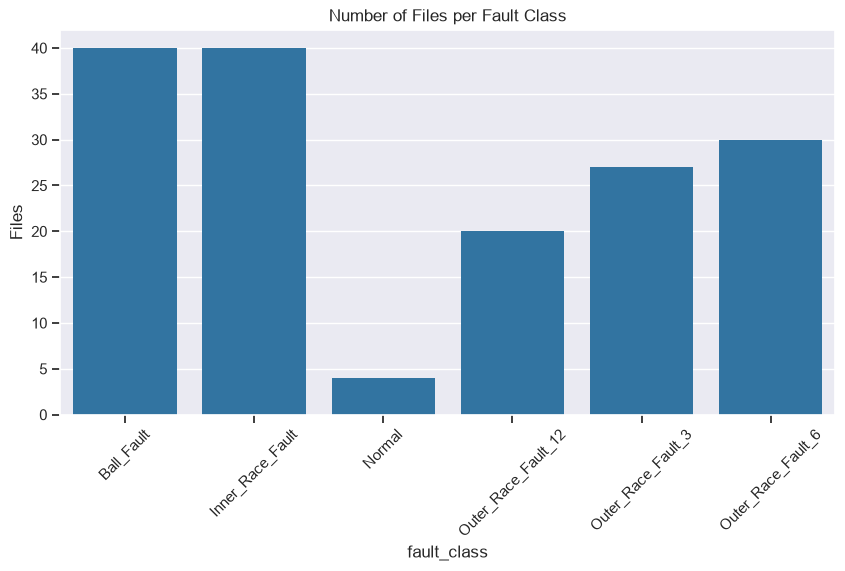

In [11]:
class_dist = df_info.groupby('fault_class').agg(
    Files=('file_id', 'count'),
    Total_Samples=('length', 'sum')
).reset_index()

display(class_dist)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_dist, x='fault_class', y='Files')
plt.title("Number of Files per Fault Class")
plt.xticks(rotation=45)
plt.show()

## 03. Raw Vibration Analysis and 04. FFT Analysis
We plot the raw waveform and the frequency spectrum (FFT) for a representative sample of each class.

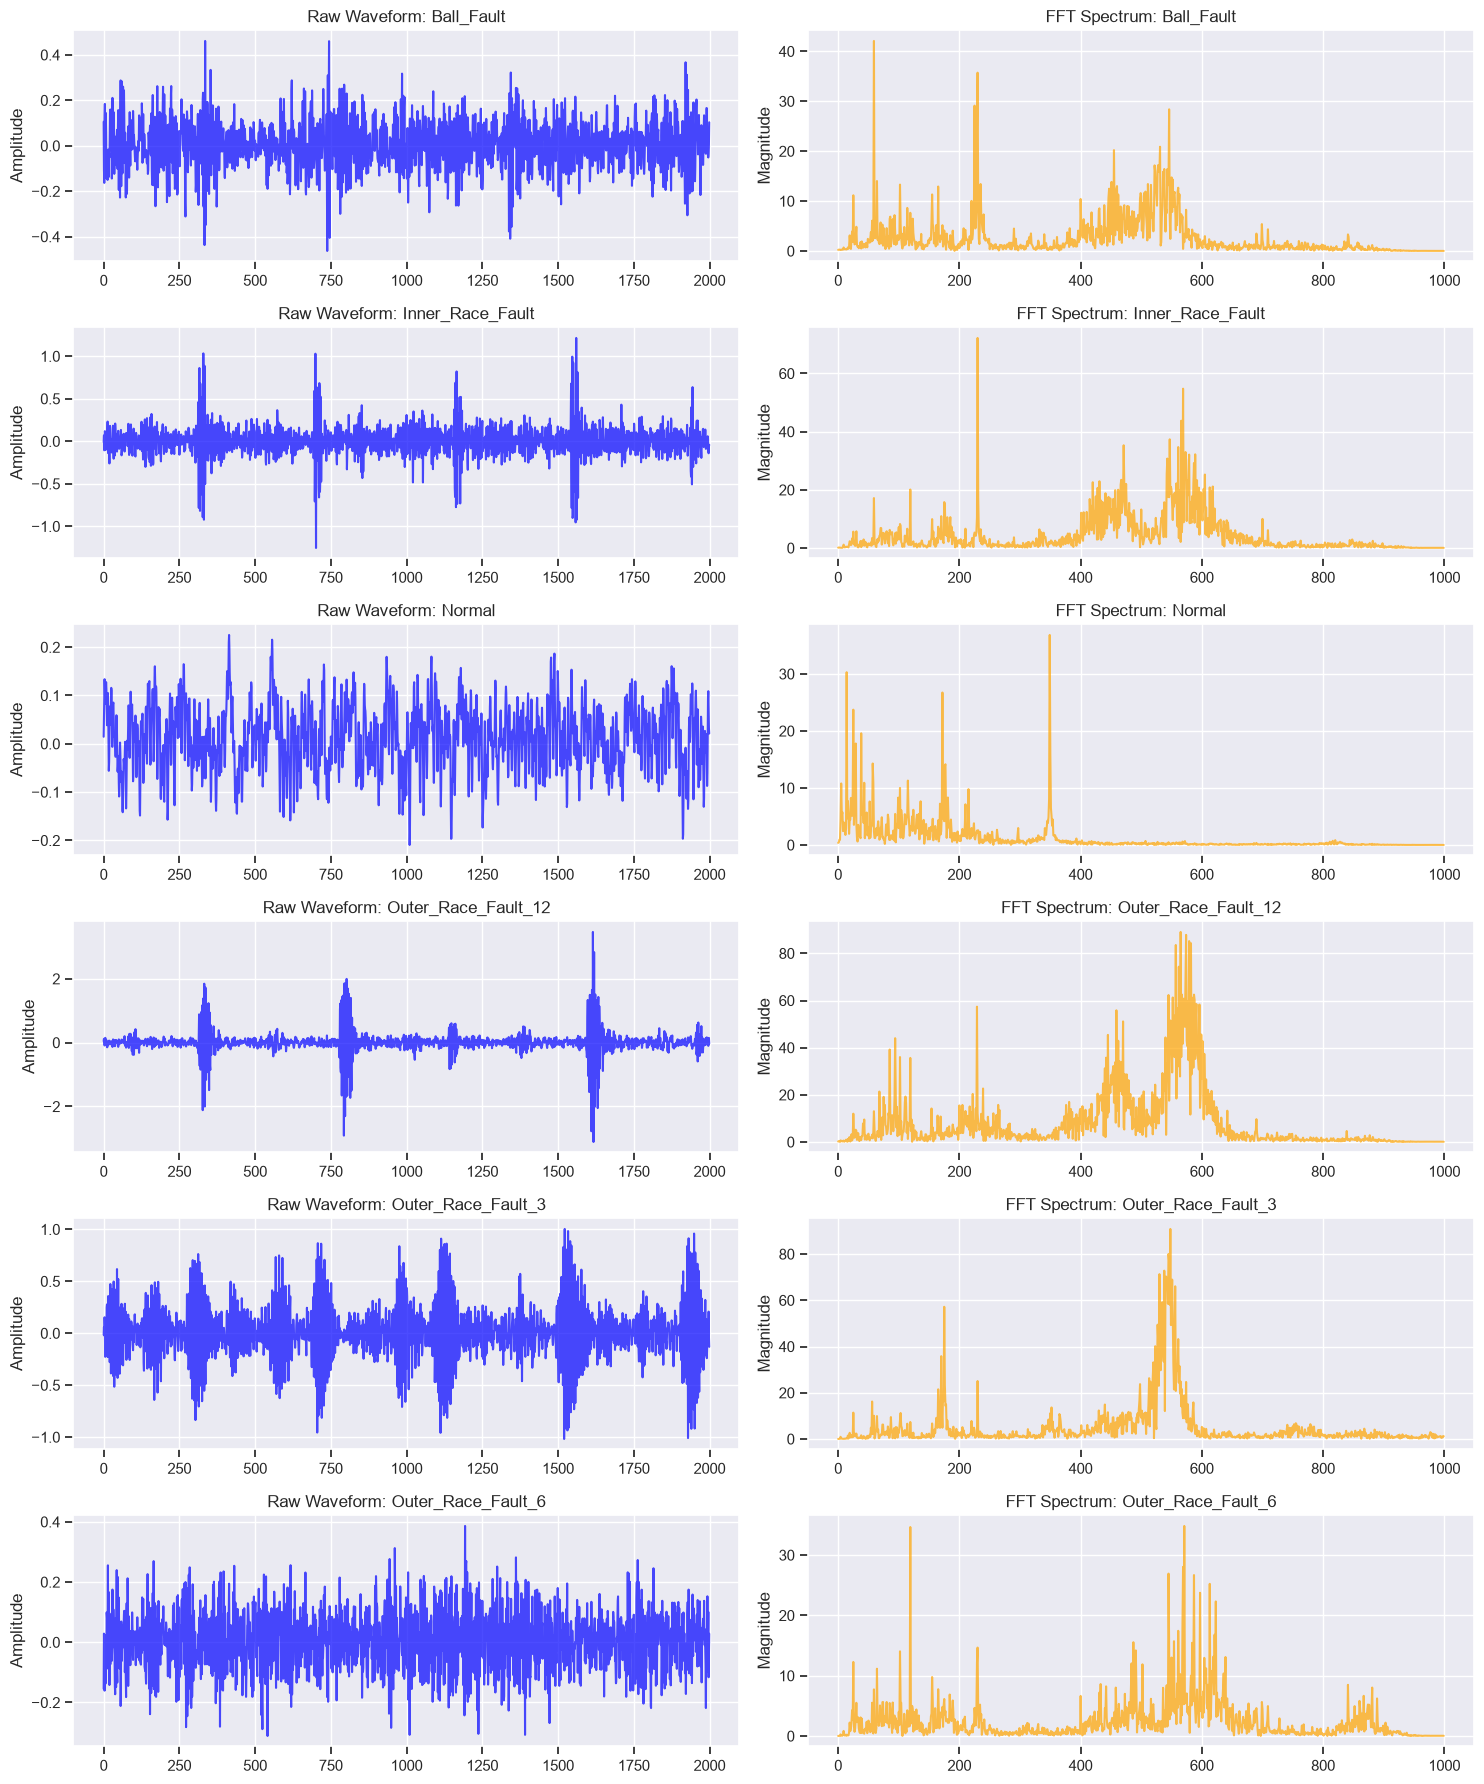

In [12]:
unique_classes = df_info['fault_class'].unique()
fig, axes = plt.subplots(len(unique_classes), 2, figsize=(15, 3 * len(unique_classes)))

for i, cls in enumerate(unique_classes):
    # Get the first record of this class
    record = next(item for item in data_records if item["fault_class"] == cls)
    signal = record['signal'][:2000] # Just plot first 2000 points
    
    # Raw waveform
    axes[i, 0].plot(signal, color='blue', alpha=0.7)
    axes[i, 0].set_title(f"Raw Waveform: {cls}")
    axes[i, 0].set_ylabel("Amplitude")
    
    # FFT
    fft_vals = np.abs(np.fft.rfft(signal))
    axes[i, 1].plot(fft_vals[1:], color='orange', alpha=0.7) # Skip DC component
    axes[i, 1].set_title(f"FFT Spectrum: {cls}")
    axes[i, 1].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

## 05, 06, 07, 08. Feature Engineering, Normalization, and Windowing
We normalize the signal per file, slice it into 1024-point non-overlapping windows, and compute Time and Frequency domain features.

In [13]:
WINDOW_SIZE = 1024
windows = []

for record in data_records:
    signal = record['signal']
    file_id = record['file_id']
    fault_class = record['fault_class']
    
    # Normalize per source file to prevent amplitude leakage
    norm_signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
    
    # Create windows
    num_windows = len(norm_signal) // WINDOW_SIZE
    for w in range(num_windows):
        start = w * WINDOW_SIZE
        end = start + WINDOW_SIZE
        window_data = norm_signal[start:end]
        
        # Time Domain Features
        mean_val = np.mean(window_data)
        std_val = np.std(window_data)
        rms_val = np.sqrt(np.mean(window_data**2))
        peak_val = np.max(np.abs(window_data))
        p2p_val = np.max(window_data) - np.min(window_data)
        crest_factor = peak_val / rms_val if rms_val > 0 else 0
        
        # Frequency Domain Features
        fft_vals = np.abs(np.fft.rfft(window_data))
        fft_mean = np.mean(fft_vals)
        fft_std = np.std(fft_vals)
        fft_max = np.max(fft_vals)
        fft_rms = np.sqrt(np.mean(fft_vals**2))
        
        windows.append({
            'file_id': file_id,
            'fault_class': fault_class,
            'window_id': w,
            'signal_window': window_data, # For 1D CNN
            # Engineered Features for SVM/RF
            'rpm': record['rpm'],
            'mean': mean_val,
            'std': std_val,
            'rms': rms_val,
            'peak': peak_val,
            'p2p': p2p_val,
            'crest_factor': crest_factor,
            'fft_mean': fft_mean,
            'fft_std': fft_std,
            'fft_max': fft_max,
            'fft_rms': fft_rms
        })

df_windows = pd.DataFrame(windows)
print(f"Total windows generated: {len(df_windows)}")

Total windows generated: 34964


## 09. Leakage-Safe Split
We must split the data by `file_id` (the original source file/run) so that adjacent windows from the same continuous recording do not leak across the train/validation/test boundaries.

In [14]:
# Splitting by file_id using GroupShuffleSplit
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(gss_test.split(df_windows, groups=df_windows['file_id']))

train_val_df = df_windows.iloc[train_val_idx].reset_index(drop=True)
test_df = df_windows.iloc[test_idx].reset_index(drop=True)

# Split train and val
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED) # ~15% of total
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['file_id']))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Train windows: {len(train_df)}")
print(f"Val windows: {len(val_df)}")
print(f"Test windows: {len(test_df)}")

# Verify no leakage
train_files = set(train_df['file_id'])
val_files = set(val_df['file_id'])
test_files = set(test_df['file_id'])

assert len(train_files.intersection(val_files)) == 0, "Leakage detected between Train and Val!"
assert len(train_files.intersection(test_files)) == 0, "Leakage detected between Train and Test!"
print("Leakage check passed! No shared files between splits.")

Train windows: 22723
Val windows: 5943
Test windows: 6298
Leakage check passed! No shared files between splits.


## 10. Save Processed Cache
We extract the components needed for modeling and save them.

In [15]:
features_cols = ['rpm', 'mean', 'std', 'rms', 'peak', 'p2p', 'crest_factor', 'fft_mean', 'fft_std', 'fft_max', 'fft_rms']

cache_data = {
    'X_train_feat': train_df[features_cols].values,
    'X_train_sig': np.stack(train_df['signal_window'].values),
    'y_train': train_df['fault_class'].values,
    
    'X_val_feat': val_df[features_cols].values,
    'X_val_sig': np.stack(val_df['signal_window'].values),
    'y_val': val_df['fault_class'].values,
    
    'X_test_feat': test_df[features_cols].values,
    'X_test_sig': np.stack(test_df['signal_window'].values),
    'y_test': test_df['fault_class'].values,
    
    'feature_names': features_cols
}

with open(os.path.join(CACHE_DIR, "cwru_processed.pkl"), "wb") as f:
    pickle.dump(cache_data, f)
    
print("CWRU pipeline complete and cache exported!")

CWRU pipeline complete and cache exported!
